# Análisis Exploratorio de Datos (EDA) — Taller 1

## Caso: Predicción de brotes de dengue

**Grupo 3**

---

Este cuaderno sigue la **misma estructura metodológica** de la guía del profesor (`EDA_Guia_Automoviles.ipynb`), adaptada al caso de **dengue** del equipo.

El flujo que seguiremos es:

> **Pregunta SMART + Hipótesis → Diccionario de datos → Visión general → Limpieza → Análisis univariado → Análisis bivariado → Conclusiones**

Documentación complementaria: [`docs/taller1/`](../docs/taller1/) · [`docs/datos/fuentes_y_diccionario.md`](../docs/datos/fuentes_y_diccionario.md)


---
# 1. El problema de negocio y la Pregunta SMART

> *Etapa del flujo: **Pregunta SMART + Hipótesis***

Antes de escribir una sola línea de código, todo análisis exploratorio riguroso debe partir de un **problema de negocio claramente delimitado**.

Ver detalle completo en [`docs/taller1/definicion_problema.md`](../docs/taller1/definicion_problema.md).

## 1.1. Contexto del negocio

El aumento recurrente de casos de **dengue** en el territorio nacional genera **sobrecarga hospitalaria** e **incremento en la mortalidad**, constituyendo una amenaza directa para la salud pública.

Trabajamos con datos de **SIVIGILA** (INS), evento **210 — Dengue**, que registran notificaciones individuales de casos con información epidemiológica, territorial y clínica. El objetivo del análisis es orientar la **vigilancia epidemiológica** y la **respuesta sanitaria territorial** mediante analítica predictiva.

La dirección de salud pública plantea la siguiente inquietud:

> *"¿Qué territorios y periodos concentran mayor riesgo de brotes y fallecimientos por dengue, y qué variables permiten anticiparlos?"*

| Aspecto | Descripción |
|---------|-------------|
| **Tipo de analítica** | **Predictiva** — anticipar territorios y periodos con mayor riesgo |
| **Tipo de problema de IA** | **Regresión** — estimar casos y fallecimientos esperados por municipio |
| **Métricas clave** | Tasa de mortalidad, incidencia de casos, fallecimientos por territorio |
| **Impacto esperado** | Reducir mortalidad, mejorar respuesta sanitaria, ampliar vigilancia en municipios de alto riesgo |

## 1.2. Formulación de la Pregunta SMART

Ver desglose en [`docs/taller1/pregunta_smart.md`](../docs/taller1/pregunta_smart.md).

> **Pregunta SMART:** ¿Puede un sistema de analítica predictiva basado en inteligencia artificial anticipar brotes de dengue con una **precisión superior al 80 %**, permitiendo reducir en al menos **20 %** la tasa de mortalidad y en **30 %** el tiempo de respuesta sanitaria en los territorios priorizados durante un **piloto de 6 meses**, utilizando datos epidemiológicos, climáticos y demográficos del **Instituto Nacional de Salud** y el **IDEAM**?

| Criterio | Cómo se cumple |
|----------|----------------|
| **Específica** | Sistema predictivo con IA, brotes de dengue, datos INS e IDEAM |
| **Medible** | Precisión > 80 % · mortalidad −20 % · respuesta −30 % |
| **Accionable** | Alertas tempranas y priorización territorial |
| **Realista** | Fuentes oficiales (INS, IDEAM, DANE) y técnicas validadas |
| **Temporal** | Piloto de **6 meses** |

## 1.3. Hipótesis de trabajo

A partir del conocimiento del dominio y el estado del arte (ver [`docs/taller1/justificacion_ia.md`](../docs/taller1/justificacion_ia.md)), planteamos hipótesis que el EDA deberá confirmar o refutar:

| ID | Hipótesis | Variables involucradas |
|----|-----------|------------------------|
| **H1** | Existe **estacionalidad**: los casos se concentran en ciertos meses/semanas epidemiológicas | `ANO`, `SEMANA`, `FEC_NOT` |
| **H2** | Hay **heterogeneidad territorial**: algunos departamentos/municipios concentran más casos y fallecimientos | `COD_DPTO_O`, `Departamento_ocurrencia`, `Municipio_ocurrencia` |
| **H3** | Variables climáticas (temperatura, lluvia, humedad) se **asocian positivamente** con la incidencia de brotes | IDEAM + agregación temporal/territorial |
| **H4** | La **hospitalización** y el **perfil demográfico** (edad, sexo) difieren entre territorios de alto y bajo riesgo | `PAC_HOS`, `EDAD`, `SEXO` |
| **H5** | El dataset epidemiológico es **suficiente y de calidad** para alimentar un modelo de regresión con meta de precisión > 80 % | Calidad global del EDA |



---
# 2. Carga del conjunto de datos

> *Etapa del flujo: **Carga de datos***

### Fuentes disponibles

| Fuente | Ubicación | Estado |
|--------|-----------|--------|
| **INS / SIVIGILA** (evento 210) | `data/raw/Datos_YYYY_210.xlsx` (2019–2025) | ✅ Descargado (~872k registros) |
| **IDEAM** (clima) | Pendiente | ⬜ Por integrar |
| **DANE** (demografía) | Pendiente | ⬜ Por integrar |

- **Drive equipo:** [Google Drive — Grupo 3](https://drive.google.com/drive/u/1/folders/1NzXBrdwk3EW74dB6GLmYZ_qp86arPvtH)
- **Utilidades del repo:** `src/config.py`, `src/load_data.py`

### Estrategia para no colapsar el notebook

Los 7 Excel juntos (~872k filas) pueden tardar **>10 min** y usar **>2 GB de RAM**. Por eso usamos **3 modos de carga**:

| Modo | Cuándo usarlo | Tiempo aprox. |
|------|---------------|---------------|
| `year` | Desarrollar y depurar el EDA | ~1–2 min (un año) |
| `sample` | Probar gráficos con dataset grande | segundos |
| `parquet` | Análisis final con todos los años | segundos |

**Paso único (fuera del notebook):** generar el Parquet una vez en terminal:

```bash
uv run python -m src.load_data
```

Eso crea `data/processed/dengue_sivigila.parquet`. Luego en el notebook cambias `MODO = "parquet"` o `MODO = "sample"`.


In [1]:
# Importación de librerías
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Permite importar desde src/ al ejecutar el notebook
PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / "src").exists() and (PROJECT_ROOT.parent / "src").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.config import DATA_RAW, DATA_PROCESSED, DENGUE_PARQUET
from src.load_data import list_raw_files, list_dengue_years, load_dengue

# Configuración estética
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.titlesize"] = 13
pd.set_option("display.max_columns", None)

print(f"Proyecto: {PROJECT_ROOT}")
print(f"Archivos en data/raw: {len(list_raw_files())}")
print(f"Años dengue disponibles: {list_dengue_years()}")
print(f"Parquet listo: {DENGUE_PARQUET.exists()}")


Proyecto: /home/v1151969298/Documentos/development/proyecto_analisis_de_datos_I
Archivos en data/raw: 7
Años dengue disponibles: [2019, 2020, 2021, 2022, 2023, 2024, 2025]
Parquet listo: False


In [2]:
# --- Configuración de carga (cambia según la etapa del EDA) ---
MODO = "year"       # "year" | "sample" | "parquet"
ANIO = 2025         # solo si MODO == "year"
FRACCION = 0.05     # solo si MODO == "sample" (5% ≈ 43k filas)

df = load_dengue(MODO, year=ANIO, sample_frac=FRACCION)

print(f"Modo: {MODO}")
print(f"Dimensiones: {df.shape[0]:,} filas × {df.shape[1]} columnas")
print(f"Memoria aprox.: {df.memory_usage(deep=True).sum() / 1e6:.1f} MB")
print(f"COD_EVE: {df['COD_EVE'].unique()}")
print(f"Años en df: {sorted(df['ANO'].unique())}")


Modo: year
Dimensiones: 120,564 filas × 70 columnas
Memoria aprox.: 47.2 MB
COD_EVE: [210]
Años en df: [np.int64(2025)]


---
# 3. Diccionario de datos

> *Etapa del flujo: **Diccionario de datos***

El diccionario describe el **significado, tipo y relevancia** de cada variable. Documentación completa en [`docs/datos/fuentes_y_diccionario.md`](../docs/datos/fuentes_y_diccionario.md).

Para cada variable clave documentamos:

- **Variable:** nombre de la columna
- **Tipo:** numérica, categórica, fecha
- **Descripción:** qué representa
- **Relevancia:** objetivo / predictora / contexto / descartar

## 3.1. Diccionario del conjunto de datos SIVIGILA (evento 210)

### Variables objetivo y de desenlace

| Variable | Tipo | Descripción | Relevancia |
|----------|------|-------------|------------|
| `CONSECUTIVE` | int | Identificador único del registro | Clave primaria |
| `confirmados` | int | Caso confirmado (1=Sí, 0=No) | Filtro de casos |
| `CON_FIN` / `Estado_final_de_caso` | int | Condición final del paciente | Desenlace clínico |
| `FEC_DEF` | fecha | Fecha de defunción | **Mortalidad** (100% nulos en muestra — validar) |
| `PAC_HOS` | int | Hospitalizado (1=Sí, 2=No) | Severidad |
| `nom_est_f_caso` | texto | Estado final (lab, probable, etc.) | Clasificación |

### Variables temporales

| Variable | Tipo | Descripción | Relevancia |
|----------|------|-------------|------------|
| `ANO` | int | Año de notificación | Serie temporal |
| `SEMANA` | int | Semana epidemiológica | Agregación temporal |
| `FEC_NOT` | texto/fecha | Fecha de notificación | Convertir a datetime |
| `INI_SIN` | texto/fecha | Inicio de síntomas | Latencia del brote |

### Variables territoriales

| Variable | Tipo | Descripción | Relevancia |
|----------|------|-------------|------------|
| `COD_DPTO_O` / `Departamento_ocurrencia` | int/texto | Departamento de ocurrencia | **Análisis territorial** |
| `COD_MUN_O` / `Municipio_ocurrencia` | int/texto | Municipio de ocurrencia | **Unidad de agregación** |
| `AREA` | int | Urbana / Rural | Contexto |

### Variables demográficas y clínicas

| Variable | Tipo | Descripción | Relevancia |
|----------|------|-------------|------------|
| `EDAD` / `UNI_MED` | int | Edad y unidad (años/meses/días) | Perfil epidemiológico |
| `SEXO` | texto | Sexo (M/F) | Perfil epidemiológico |
| `TIP_CAS` | int | Tipo de caso (2=Probable, 3=Confirmado) | Clasificación |

### Variables pendientes (otras fuentes)

| Fuente | Variables | Estado |
|--------|-----------|--------|
| IDEAM | Temperatura, lluvia, humedad | ⬜ Pendiente integrar |
| DANE | Población, densidad | ⬜ Pendiente integrar |
| Secretarías de Salud | Saneamiento, criaderos | ⬜ Pendiente integrar |


In [5]:
# Construimos el diccionario de variables clave como DataFrame (guía del profesor)
columnas_clave = [
    "CONSECUTIVE", "ANO", "SEMANA", "FEC_NOT", "EDAD", "UNI_MED", "SEXO",
    "COD_DPTO_O", "Departamento_ocurrencia", "COD_MUN_O", "Municipio_ocurrencia",
    "confirmados", "PAC_HOS", "CON_FIN", "FEC_DEF", "nom_est_f_caso", "TIP_CAS", "AREA",
]

diccionario = pd.DataFrame({
    "variable": columnas_clave,
    "tipo": [
        "int", "int", "int", "texto/fecha", "int", "int", "categórico",
        "int", "categórico", "int", "categórico",
        "int", "int", "int", "fecha", "categórico", "int", "int",
    ],
    "descripcion": [
        "Identificador único del registro",
        "Año de notificación",
        "Semana epidemiológica",
        "Fecha de notificación del caso",
        "Edad del paciente",
        "Unidad de edad (1=años, 2=meses, 3=días)",
        "Sexo del paciente (M/F)",
        "Código DANE del departamento de ocurrencia",
        "Nombre del departamento de ocurrencia",
        "Código DANE del municipio de ocurrencia",
        "Nombre del municipio de ocurrencia",
        "Caso confirmado (1=Sí, 0=No)",
        "Hospitalizado (1=Sí, 2=No)",
        "Condición final del paciente",
        "Fecha de defunción",
        "Estado final del caso (lab, probable, etc.)",
        "Tipo de caso (2=Probable, 3=Confirmado)",
        "Área (1=Urbana, 2=Rural, 3=Urbana-rural)",
    ],
    "relevancia": [
        "Clave primaria", "Serie temporal", "Agregación temporal", "Convertir a datetime",
        "Perfil epidemiológico", "Normalizar edad", "Perfil epidemiológico",
        "Análisis territorial", "Reportes/mapas", "Unidad de agregación", "Reportes/mapas",
        "Filtro de casos", "Severidad", "Desenlace clínico", "Mortalidad", "Clasificación",
        "Clasificación", "Contexto",
    ],
})

diccionario

,variable,tipo,descripcion,relevancia
0,CONSECUTIVE,int,Identificador único del registro,Clave primaria
1,ANO,int,Año de notificación,Serie temporal
2,SEMANA,int,Semana epidemiológica,Agregación temporal
3,FEC_NOT,texto/fecha,Fecha de notificación del caso,Convertir a datetime
4,EDAD,int,Edad del paciente,Perfil epidemiológico
5,UNI_MED,int,"Unidad de edad (1=años, 2=meses, 3=días)",Normalizar edad
6,SEXO,categórico,Sexo del paciente (M/F),Perfil epidemiológico
7,COD_DPTO_O,int,Código DANE del departamento de ocurrencia,Análisis territorial
8,Departamento_ocurrencia,categórico,Nombre del departamento de ocurrencia,Reportes/mapas
9,COD_MUN_O,int,Código DANE del municipio de ocurrencia,Unidad de agregación


---
# 4. Visión general del conjunto de datos

> *Etapa del flujo: **Visión general (formato, nombres, tipos, unidades, columnas redundantes)***

Antes de entrar al detalle, obtenemos una **fotografía global** del dataset.

## 4.1. Primeras filas del conjunto de datos

In [6]:
# El método head() permite una inspección visual rápida de los registros.
df.head(10)

,CONSECUTIVE,COD_EVE,FEC_NOT,SEMANA,ANO,COD_PRE,COD_SUB,EDAD,UNI_MED,SEXO,COD_PAIS_O,COD_DPTO_O,COD_MUN_O,AREA,OCUPACION,TIP_SS,COD_ASE,PER_ETN,GRU_POB,nom_grupo,estrato,GP_DISCAPA,GP_DESPLAZ,GP_MIGRANT,GP_CARCELA,GP_GESTAN,sem_ges,GP_INDIGEN,GP_POBICFB,GP_MAD_COM,GP_DESMOVI,GP_PSIQUIA,GP_VIC_VIO,GP_OTROS,fuente,COD_PAIS_R,COD_DPTO_R,COD_MUN_R,COD_DPTO_N,COD_MUN_N,FEC_CON,INI_SIN,TIP_CAS,PAC_HOS,FEC_HOS,CON_FIN,FEC_DEF,AJUSTE,FECHA_NTO,CBMTE,FEC_ARC_XL,FEC_AJU,FM_FUERZA,FM_UNIDAD,FM_GRADO,confirmados,va_sispro,Estado_final_de_caso,nom_est_f_caso,Nombre_upgd,Pais_ocurrencia,Nombre_evento,Departamento_ocurrencia,Municipio_ocurrencia,Pais_residencia,Departamento_residencia,Municipio_residencia,Departamento_Notificacion,Municipio_notificacion,archivo_origen
0,23659,210,30/03/2025 12:00:00 a. m.,12,2025,8173600067,1,17,1,F,170,81,65,1,99999.07,S,EPSS41,6,NaN,...,1,2,2,2,2,2,,2,2,2,2,2,2,1,1,170,81,736,81,81736,28/03/2025 12:00:00 a. m.,22/03/2025 12:00:00 a. m.,3,1,28/03/2025 12:00:00 a. m.,1,NaN,0,28/01/2008 12:00:00 a. m.,NaN,2/04/2025 12:00:00 a. m.,2/04/2025 12:00:00 a. m.,NaN,NaN,NaN,1,1,3,Confirmado por laboratorio,ESE HOSPITAL DEL SARARE,COLOMBIA,DENGUE,ARAUCA,ARAUQUITA,COLOMBIA,ARAUCA,SARAVENA,ARAUCA,SARAVENA,2025
1,28950,210,7/01/2025 12:00:00 a. m.,2,2025,2300101129,2,15,1,F,170,23,466,1,99999.05,S,EPSS37,6,NaN,...,1,2,2,2,2,2,,2,2,2,2,2,2,1,1,170,23,466,23,23001,7/01/2025 12:00:00 a. m.,7/01/2025 12:00:00 a. m.,3,1,7/01/2025 12:00:00 a. m.,1,NaN,0,25/12/2009 12:00:00 a. m.,NaN,10/01/2025 12:00:00 a. m.,10/01/2025 12:00:00 a. m.,NaN,NaN,NaN,1,1,3,Confirmado por laboratorio,CENTRO CARDIOINFANTIL IPS EU,COLOMBIA,DENGUE,CORDOBA,MONTELIBANO,COLOMBIA,CORDOBA,MONTELIBANO,CORDOBA,MONTERIA,2025
2,28949,210,18/08/2025 12:00:00 a. m.,34,2025,2300100542,1,15,1,F,170,23,580,1,99999.04,S,ESS024,6,NaN,...,1,2,2,2,2,1,34,2,2,2,2,2,2,2,1,170,23,580,23,23001,18/08/2025 12:00:00 a. m.,18/08/2025 12:00:00 a. m.,3,1,18/08/2025 12:00:00 a. m.,1,NaN,0,3/10/2009 12:00:00 a. m.,NaN,22/08/2025 12:00:00 a. m.,22/08/2025 12:00:00 a. m.,NaN,NaN,NaN,1,1,3,Confirmado por laboratorio,CLINICA MONTERIA SA,COLOMBIA,DENGUE,CORDOBA,PUERTO LIBERTADOR,COLOMBIA,CORDOBA,PUERTO LIBERTADOR,CORDOBA,MONTERIA,2025
3,29728,210,8/01/2025 12:00:00 a. m.,2,2025,2300100487,2,3,1,M,170,5,604,1,99999.07,S,ESS024,6,NaN,...,1,2,2,2,2,2,,2,2,2,2,2,2,1,1,170,5,604,23,23001,8/01/2025 12:00:00 a. m.,7/01/2025 12:00:00 a. m.,3,1,8/01/2025 12:00:00 a. m.,1,NaN,0,25/01/2021 12:00:00 a. m.,NaN,15/01/2025 12:00:00 a. m.,15/01/2025 12:00:00 a. m.,NaN,NaN,NaN,1,1,3,Confirmado por laboratorio,CLINICA MATERNO INFANTIL CASA DEL NIÑO LTDA,COLOMBIA,DENGUE,ANTIOQUIA,REMEDIOS,COLOMBIA,ANTIOQUIA,REMEDIOS,CORDOBA,MONTERIA,2025
4,29813,210,27/01/2025 12:00:00 a. m.,3,2025,1300100085,1,20,1,F,170,13,1,1,99999.05,S,ESS207,6,NaN,...,1,2,2,2,2,2,,2,2,2,2,2,2,1,1,170,13,1,13,13001,24/01/2025 12:00:00 a. m.,18/01/2025 12:00:00 a. m.,2,1,24/01/2025 12:00:00 a. m.,1,NaN,3,31/01/2004 12:00:00 a. m.,NaN,4/03/2025 12:00:00 a. m.,4/03/2025 12:00:00 a. m.,NaN,NaN,NaN,1,1,3,Confirmado por laboratorio,CLINICA CARTAGENA DEL MAR S.A.,COLOMBIA,DENGUE,BOLIVAR,CARTAGENA,COLOMBIA,BOLIVAR,CARTAGENA,BOLIVAR,CARTAGENA,2025
5,28988,210,12/12/2025 12:00:00 a. m.,50,2025,1367000076,1,20,1,M,170,13,670,3,99999.04,S,CCF055,6,NaN,...,1,2,2,2,2,2,,2,2,2,2,2,2,1,1,170,13,670,13,13670,12/12/2025 12:00:00 a. m.,7/12/2025 12:00:00 a. m.,3,2,NaN,1,NaN,0,30/05/2005 12:00:00 a. m.,NaN,16/12/2025 12:00:00 a. m.,16/12/2025 12:00:00 a. m.,NaN,NaN,NaN,1,1,3,Confirmado por laboratorio,ESE HOSPITAL LOCAL SAN PABLO,COLOMBIA,DENGUE,BOLIVAR,SAN PABLO,COLOMBIA,BOLIVAR,SAN PABLO,BOLIVAR,SAN PABLO,2025
6,1872,210,15/09/2025 12:00:00 a. m.,37,2025,2300100487,2,16,1,M,170,23,1,1,99999.05,S,ESS207,6,NaN,...,1,2,2,2,2,2,,2,2,2,2,2,2,1,1,170,23,1,23,23001,15/09/2025 12:00:00 a. m.,10/09/2025 12:00:00 a. m.,3,1,15/09/2025 12:00:00 a. m.,1,NaN,0,3/04/2009 12:00:00 a. m.,NaN,16/09/2025 12:00:00 a. m.,16/09/2025 12:00:00 a. m.,NaN,NaN,NaN,1,1,3,Confirma

## 4.2. Estructura, tipos de datos y memoria

Revisar si columnas numéricas aparecen como `object` (fechas en texto, códigos mixtos).

In [7]:
# info() resume registros no nulos y tipo de dato por columna.
df.info()
print(f"Memoria: {df.memory_usage(deep=True).sum() / 1e6:.1f} MB")

<class 'pandas.DataFrame'>
RangeIndex: 120564 entries, 0 to 120563
Data columns (total 70 columns):
 #   Column                     Non-Null Count   Dtype   
---  ------                     --------------   -----   
 0   CONSECUTIVE                120564 non-null  int64   
 1   COD_EVE                    120564 non-null  int64   
 2   FEC_NOT                    120564 non-null  category
 3   SEMANA                     120564 non-null  int64   
 4   ANO                        120564 non-null  int64   
 5   COD_PRE                    120564 non-null  int64   
 6   COD_SUB                    120564 non-null  int64   
 7   EDAD                       120564 non-null  int64   
 8   UNI_MED                    120564 non-null  int64   
 9   SEXO                       120564 non-null  category
 10  COD_PAIS_O                 120564 non-null  int64   
 11  COD_DPTO_O                 120564 non-null  int64   
 12  COD_MUN_O                  120564 non-null  int64   
 13  AREA                     

## 4.3. Dimensiones, columnas y valores únicos

Evaluar cardinalidad de variables categóricas (departamentos, municipios, UPGD).

In [10]:
print("Filas:", df.shape[0], "| Columnas:", df.shape[1])
print("-" * 60)
print("Años:", sorted(df["ANO"].unique()))
# FEC_NOT puede venir como texto o category: usamos str para el rango en esta etapa
fec_not = df["FEC_NOT"].astype(str)
print("Rango fechas:", fec_not.min(), "→", fec_not.max())
print("Departamentos:", df["Departamento_ocurrencia"].nunique())
print("Municipios:", df["Municipio_ocurrencia"].nunique())
print("Semanas epidemiológicas:", df["SEMANA"].nunique())
print("-" * 60)
df.nunique().sort_values(ascending=False).head(15)

Filas: 120564 | Columnas: 70
------------------------------------------------------------
Años: [np.int64(2025)]
Rango fechas: 1/01/2025 12:00:00 a. m. → 9/12/2025 12:00:00 a. m.
Departamentos: 33
Municipios: 840
Semanas epidemiológicas: 53
------------------------------------------------------------


CONSECUTIVE               120564
FECHA_NTO                  25666
Nombre_upgd                 2527
COD_PRE                     2116
Municipio_residencia         891
Municipio_ocurrencia         840
COD_MUN_N                    813
Municipio_notificacion       762
OCUPACION                    596
COD_MUN_R                    521
COD_MUN_O                    505
FEC_AJU                      454
FEC_ARC_XL                   452
FEC_NOT                      437
FEC_CON                      398
dtype: int64

## 4.4. Estadísticos descriptivos preliminares

**Sobre columnas a descartar o usar con cuidado:**

- **Identificadores:** `CONSECUTIVE` — clave, no predictor
- **Redundantes:** pares código/nombre territorial (`COD_DPTO_O` vs `Departamento_ocurrencia`)
- **100% nulos:** `FEC_DEF`, `GRU_POB`, `CBMTE` — evaluar utilidad
- ***Data leakage*:** variables posteriores al desenlace que no estarían disponibles al predecir

In [11]:
# Estadísticos de variables numéricas clave
cols_describe = ["EDAD", "SEMANA", "ANO", "PAC_HOS", "confirmados", "TIP_CAS", "AREA"]
df[cols_describe].describe().T

,count,mean,std,min,25%,50%,75%,max
EDAD,120564.0,22.588982,18.528527,1.0,9.0,16.0,31.0,104.0
SEMANA,120564.0,22.259057,15.412488,1.0,9.0,20.0,34.0,53.0
ANO,120564.0,2025.000000,0.000000,2025.0,2025.0,2025.0,2025.0,2025.0
PAC_HOS,120564.0,1.627965,0.483350,1.0,1.0,2.0,2.0,2.0
confirmados,120564.0,0.750556,0.432693,0.0,1.0,1.0,1.0,1.0
TIP_CAS,120564.0,2.418599,0.516976,2.0,2.0,2.0,3.0,5.0
AREA,120564.0,1.328149,0.687365,1.0,1.0,1.0,1.0,3.0


In [12]:
# Resumen de variables categóricas clave
for col in ["SEXO", "nom_est_f_caso", "Departamento_ocurrencia", "TIP_SS"]:
    print(f"\n--- {col} (top 5) ---")
    print(df[col].value_counts().head())


--- SEXO (top 5) ---
SEXO
M    62938
F    57626
Name: count, dtype: int64

--- nom_est_f_caso (top 5) ---
nom_est_f_caso
Confirmado por laboratorio            85842
Probable                              30074
Confirmado por Nexo Epidemiológico     4648
Name: count, dtype: int64

--- Departamento_ocurrencia (top 5) ---
Departamento_ocurrencia
BOLIVAR            11668
SANTANDER          10938
CORDOBA            10450
META               10266
NORTE SANTANDER     8415
Name: count, dtype: int64

--- TIP_SS (top 5) ---
TIP_SS
S    67545
C    45618
P     5342
N     1329
I      601
Name: count, dtype: int64


---
# 5. Limpieza y preparación de los datos

> *Etapa del flujo: preparación previa al análisis (valores perdidos, formato)*

## 5.1. Identificación de valores perdidos

### Paso 1 — Conteo de nulos por columna

In [13]:
nulos = df.isnull().sum()
nulos[nulos > 0].sort_values(ascending=False)

GRU_POB      120564
FEC_DEF      120564
CBMTE        120564
FM_FUERZA    119949
FM_UNIDAD    119949
FM_GRADO     119949
FEC_HOS       75710
COD_ASE        1930
dtype: int64

### Paso 2 — Porcentaje de valores perdidos por columna

In [14]:
pct_nulos = (df.isnull().mean() * 100).round(2)
pct_nulos[pct_nulos > 0].sort_values(ascending=False)

GRU_POB      100.00
FEC_DEF      100.00
CBMTE        100.00
FM_FUERZA     99.49
FM_UNIDAD     99.49
FM_GRADO      99.49
FEC_HOS       62.80
COD_ASE        1.60
dtype: float64

## 5.2. Tratamiento de los valores perdidos

| Variable | Estrategia aplicada |
|----------|---------------------|
| `FEC_HOS` | Conservar nulo (esperado si no hospitalizado) |
| `FEC_DEF` | Excluir columna (100% nulos en 2025) |
| `GRU_POB`, `CBMTE`, campos militares | Excluir columnas vacías |
| Filas sin municipio o fecha | Eliminar |

In [15]:
df_limpio = df.copy()

# Excluir columnas sin información útil
cols_vacias = ["GRU_POB", "CBMTE", "FEC_DEF", "FM_FUERZA", "FM_UNIDAD", "FM_GRADO"]
df_limpio = df_limpio.drop(columns=[c for c in cols_vacias if c in df_limpio.columns])

# Eliminar filas sin datos territoriales o temporales mínimos
filas_antes = len(df_limpio)
df_limpio = df_limpio.dropna(subset=["COD_MUN_O", "FEC_NOT"])
print(f"Filas eliminadas: {filas_antes - len(df_limpio):,}")
print(f"Filas restantes: {len(df_limpio):,}")

Filas eliminadas: 0
Filas restantes: 120,564


### Verificación: estado de valores perdidos tras limpieza

In [16]:
# Top columnas con nulos restantes
resto = df_limpio.isnull().sum()
resto[resto > 0].sort_values(ascending=False).head(10)

FEC_HOS    75710
COD_ASE     1930
dtype: int64

## 5.3. Corrección del formato de los datos

Convertir fechas en texto a `datetime`.

In [17]:
def parsear_fecha(serie):
    """Convierte fechas SIVIGILA (dd/mm/yyyy con 'a. m.' / 'p. m.') a datetime."""
    limpia = (
        serie.astype(str)
        .str.replace(r"\s*a\.\s*m\.", "", regex=True)
        .str.replace(r"\s*p\.\s*m\.", "", regex=True)
        .str.strip()
    )
    return pd.to_datetime(limpia, dayfirst=True, errors="coerce")

cols_fecha = ["FEC_NOT", "INI_SIN", "FEC_HOS", "FEC_CON", "FECHA_NTO"]
for col in cols_fecha:
    if col in df_limpio.columns:
        df_limpio[col] = parsear_fecha(df_limpio[col])

print("FEC_NOT convertida:", df_limpio["FEC_NOT"].dtype)
print("Rango:", df_limpio["FEC_NOT"].min(), "→", df_limpio["FEC_NOT"].max())
df_limpio[["FEC_NOT", "INI_SIN", "FEC_HOS"]].head()

/tmp/ipykernel_340185/3745574752.py:9: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  return pd.to_datetime(limpia, dayfirst=True, errors="coerce")
/tmp/ipykernel_340185/3745574752.py:9: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  return pd.to_datetime(limpia, dayfirst=True, errors="coerce")
/tmp/ipykernel_340185/3745574752.py:9: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  return pd.to_datetime(limpia, dayfirst=True, errors="coerce")
/tmp/ipykernel_340185/3745574752.py:9: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `d

FEC_NOT convertida: datetime64[us]
Rango: 2024-12-29 00:00:00 → 2026-03-27 00:00:00


,FEC_NOT,INI_SIN,FEC_HOS
0,2025-03-30,2025-03-22,2025-03-28
1,2025-01-07,2025-01-07,2025-01-07
2,2025-08-18,2025-08-18,2025-08-18
3,2025-01-08,2025-01-07,2025-01-08
4,2025-01-27,2025-01-18,2025-01-24


## 5.4. Creación de nuevas columnas (features derivadas)

In [18]:
def edad_en_anios(row):
    if row["UNI_MED"] == 1:
        return row["EDAD"]
    if row["UNI_MED"] == 2:
        return row["EDAD"] / 12
    return row["EDAD"] / 365

df_limpio["edad_anios"] = df_limpio.apply(edad_en_anios, axis=1)
df_limpio["mes"] = df_limpio["FEC_NOT"].dt.month
df_limpio["trimestre"] = df_limpio["FEC_NOT"].dt.quarter
df_limpio["hospitalizado"] = df_limpio["PAC_HOS"] == 1
df_limpio["confirmado"] = df_limpio["confirmados"] == 1
df_limpio["depto_mun"] = (
    df_limpio["COD_DPTO_O"].astype(str).str.zfill(2)
    + df_limpio["COD_MUN_O"].astype(str).str.zfill(3)
)

df_limpio[["EDAD", "UNI_MED", "edad_anios", "mes", "hospitalizado", "confirmado"]].head()

,EDAD,UNI_MED,edad_anios,mes,hospitalizado,confirmado
0,17,1,17.0,3,True,True
1,15,1,15.0,1,True,True
2,15,1,15.0,8,True,True
3,3,1,3.0,1,True,True
4,20,1,20.0,1,True,True


In [19]:
# Exportar dataset limpio del año para el equipo
DATA_PROCESSED.mkdir(parents=True, exist_ok=True)
ruta_limpio = DATA_PROCESSED / f"dengue_sivigila_{ANIO}_limpio.parquet"
df_limpio.to_parquet(ruta_limpio, index=False)
print(f"Exportado: {ruta_limpio}")
print(f"Filas: {len(df_limpio):,} | Columnas: {df_limpio.shape[1]}")

Exportado: /home/v1151969298/Documentos/development/proyecto_analisis_de_datos_I/data/processed/dengue_sivigila_2025_limpio.parquet
Filas: 120,564 | Columnas: 70


Con esto concluye la etapa de limpieza. Disponemos de un conjunto **completo, con tipos correctos y variables derivadas** listo para el análisis exploratorio.

---
# 6. Análisis univariado

> *Etapa del flujo: **Análisis univariado***

## 6.1. Variables objetivo: casos, hospitalización y perfil temporal

Preguntas guía:
- ¿Cómo se distribuyen los casos por mes y semana epidemiológica?
- ¿Cuántas hospitalizaciones hay?
- ¿Qué proporción son casos confirmados?

In [20]:
# Resumen de variables de desenlace
print("Total casos:", len(df_limpio))
print("Casos confirmados:", df_limpio["confirmado"].sum(), f"({df_limpio['confirmado'].mean()*100:.1f}%)")
print("Hospitalizados:", df_limpio["hospitalizado"].sum(), f"({df_limpio['hospitalizado'].mean()*100:.1f}%)")
print()
print("Estado final del caso:")
print(df_limpio["nom_est_f_caso"].value_counts())

Total casos: 120564
Casos confirmados: 90490 (75.1%)
Hospitalizados: 44854 (37.2%)

Estado final del caso:
nom_est_f_caso
Confirmado por laboratorio            85842
Probable                              30074
Confirmado por Nexo Epidemiológico     4648
Name: count, dtype: int64


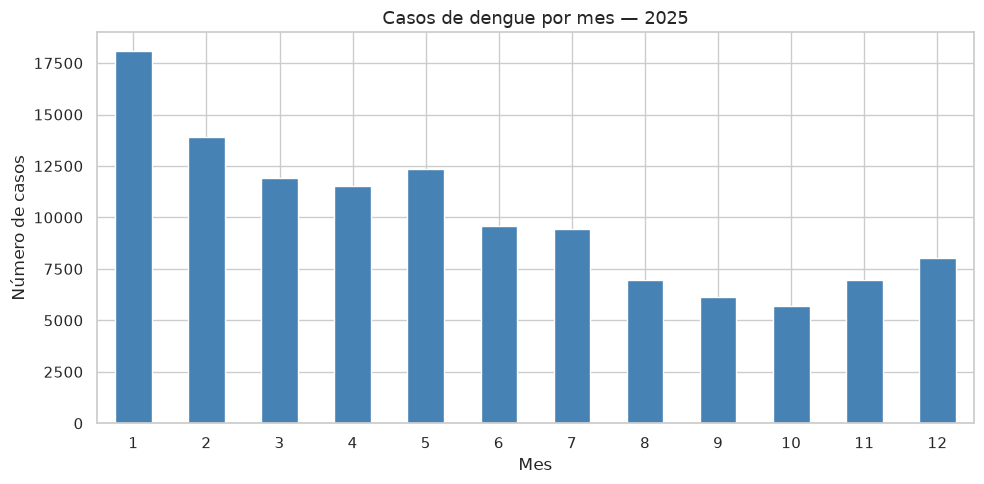

In [21]:
# Casos por mes — 2025
casos_por_mes = df_limpio.groupby("mes").size()
casos_por_mes.plot(kind="bar", color="steelblue", title=f"Casos de dengue por mes — {ANIO}")
plt.xlabel("Mes")
plt.ylabel("Número de casos")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

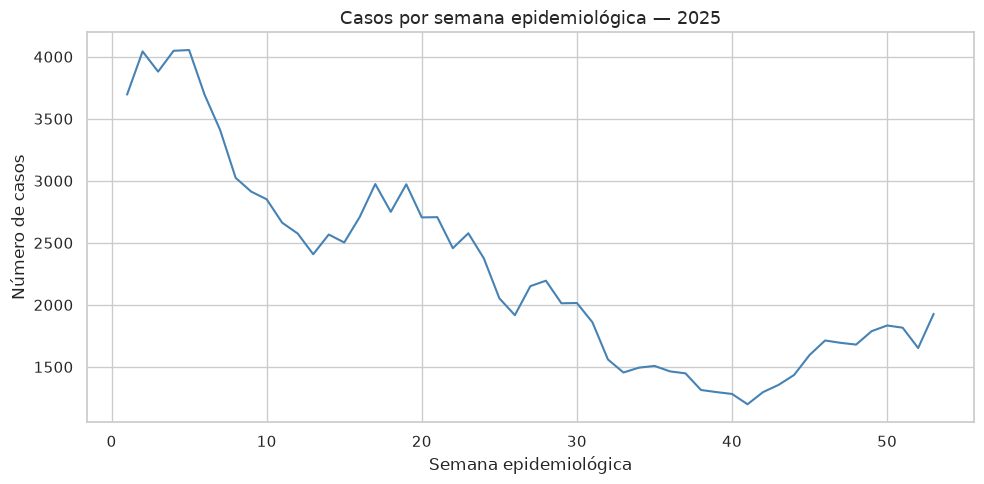

In [22]:
# Casos por semana epidemiológica — 2025
casos_por_semana = df_limpio.groupby("SEMANA").size()
casos_por_semana.plot(color="steelblue", title=f"Casos por semana epidemiológica — {ANIO}")
plt.xlabel("Semana epidemiológica")
plt.ylabel("Número de casos")
plt.tight_layout()
plt.show()

**Interpretación (completar tras ejecutar):**

- _[¿En qué meses/semanas se concentran los casos en 2025?]_
- _[¿Hay estacionalidad visible? (H1)]_
- _[Proporción de hospitalizados y confirmados]_

## 6.2. Variables numéricas continuas

Variables: `edad_anios`, `SEMANA`.

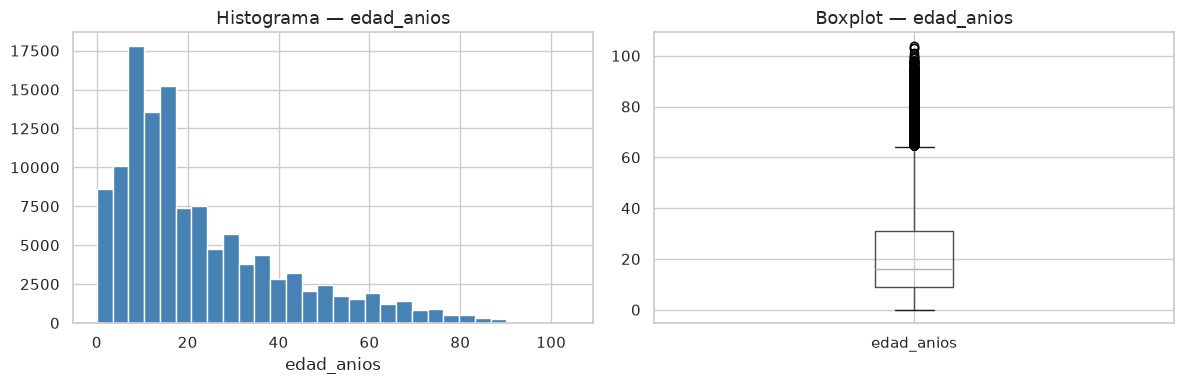

count    120564.000000
mean         22.487507
std          18.625811
min           0.002740
25%           9.000000
50%          16.000000
75%          31.000000
max         104.000000
Name: edad_anios, dtype: float64

In [23]:
def analizar_variable_continua(columna, data=df_limpio):
    """Muestra estadísticos, histograma y boxplot de una variable continua."""
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    data[columna].hist(bins=30, ax=axes[0], color="steelblue", edgecolor="white")
    axes[0].set_title(f"Histograma — {columna}")
    axes[0].set_xlabel(columna)
    data.boxplot(column=columna, ax=axes[1])
    axes[1].set_title(f"Boxplot — {columna}")
    plt.tight_layout()
    plt.show()
    display(data[columna].describe())

analizar_variable_continua("edad_anios")

### 6.2.1. Cuantificación de outliers (IQR)

> La detección de outliers **no implica** eliminación automática. Documentar y justificar.

In [24]:
def contar_outliers_iqr(columna, data=df_limpio):
    q1, q3 = data[columna].quantile([0.25, 0.75])
    iqr = q3 - q1
    mask = (data[columna] < q1 - 1.5 * iqr) | (data[columna] > q3 + 1.5 * iqr)
    n = mask.sum()
    return n, len(data), n / len(data) * 100

for col in ["edad_anios", "SEMANA"]:
    n, total, pct = contar_outliers_iqr(col)
    print(f"{col}: {n:,} outliers ({pct:.2f}% de {total:,} registros)")

edad_anios: 5,258 outliers (4.36% de 120,564 registros)
SEMANA: 0 outliers (0.00% de 120,564 registros)


## 6.3. Variables categóricas

Variables: `SEXO`, `PAC_HOS`, `nom_est_f_caso`, `Departamento_ocurrencia`, `AREA`, `TIP_SS`.

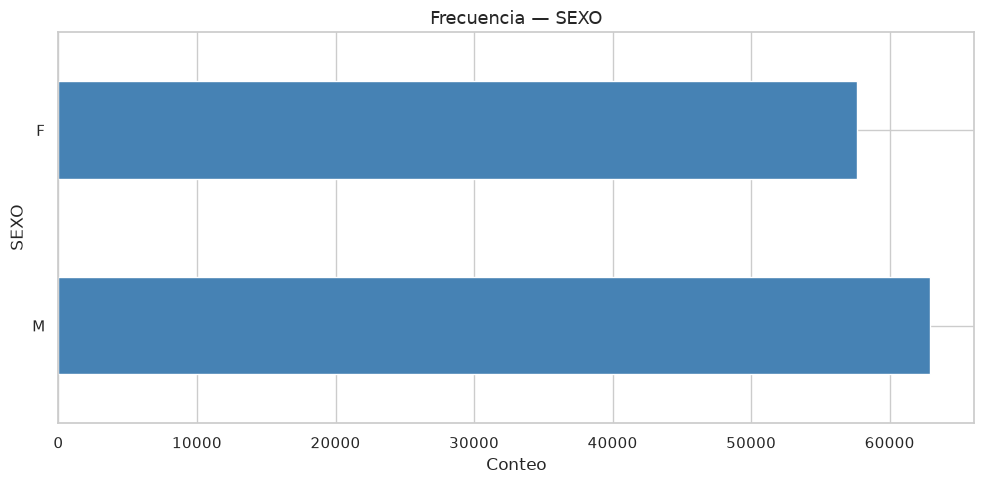

,conteo
SEXO,
M,62938
F,57626


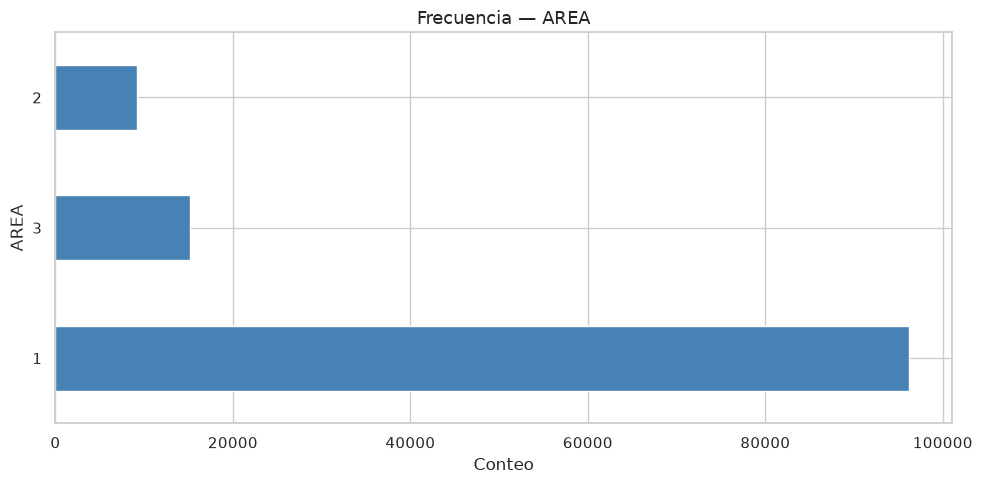

,conteo
AREA,
1,96192
3,15191
2,9181


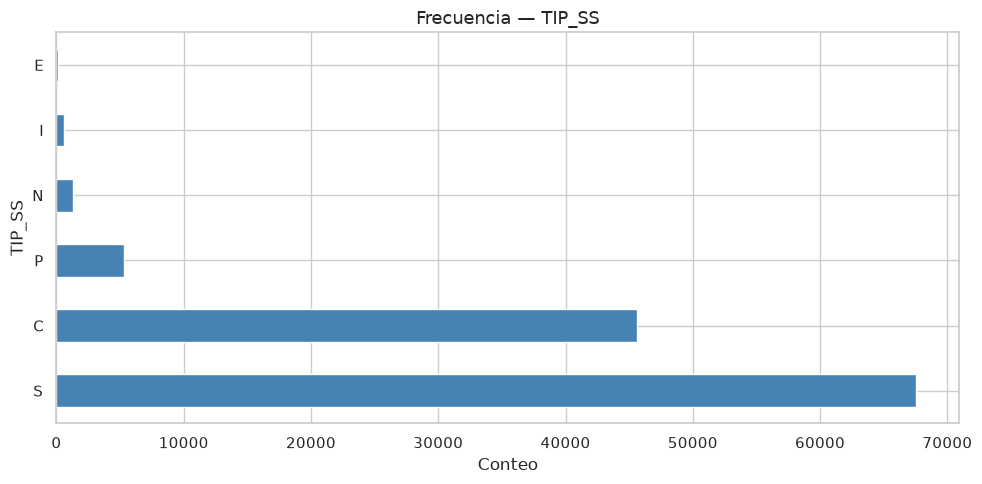

,conteo
TIP_SS,
S,67545
C,45618
P,5342
N,1329
I,601
E,129


In [25]:
def analizar_variable_categorica(columna, data=df_limpio, top_n=15):
    freq = data[columna].value_counts().head(top_n)
    freq.plot(kind="barh", color="steelblue", title=f"Frecuencia — {columna}")
    plt.xlabel("Conteo")
    plt.tight_layout()
    plt.show()
    display(freq.to_frame("conteo"))

for col in ["SEXO", "AREA", "TIP_SS"]:
    analizar_variable_categorica(col)

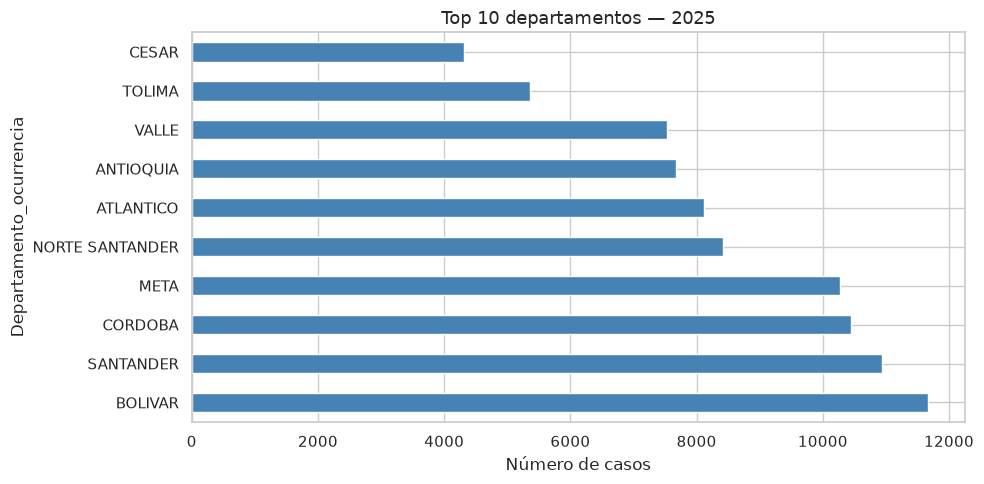

Departamento_ocurrencia
BOLIVAR            11668
SANTANDER          10938
CORDOBA            10450
META               10266
NORTE SANTANDER     8415
ATLANTICO           8117
ANTIOQUIA           7670
VALLE               7538
TOLIMA              5358
CESAR               4314
Name: count, dtype: int64

In [26]:
# Top 10 departamentos por número de casos
top_deptos = df_limpio["Departamento_ocurrencia"].value_counts().head(10)
top_deptos.plot(kind="barh", color="steelblue", title=f"Top 10 departamentos — {ANIO}")
plt.xlabel("Número de casos")
plt.tight_layout()
plt.show()
top_deptos

**Interpretación (completar tras ejecutar):**

- _[Perfil demográfico: sexo, edad]_
- _[Proporción de hospitalizados y tipos de caso]_
- _[Departamentos con mayor conteo absoluto (H2)]_

---
# 7. Análisis bivariado

> *Etapa del flujo: **Análisis bivariado***

## 7.1. Matriz de correlación (variables numéricas)

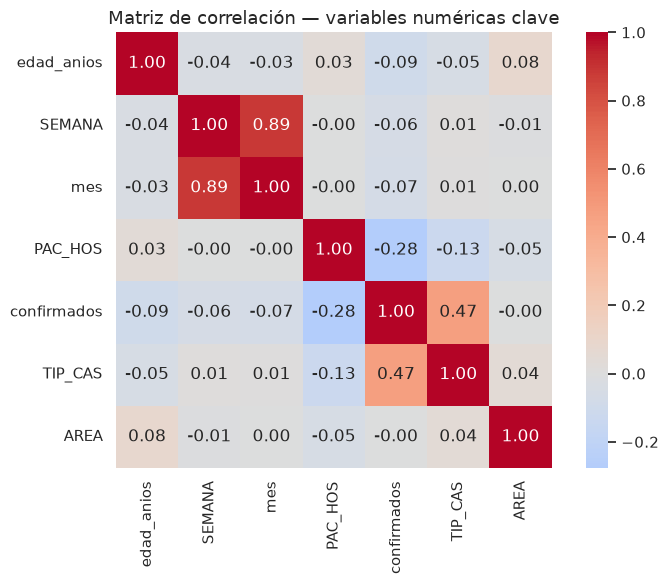

In [27]:
cols_num = ["edad_anios", "SEMANA", "mes", "PAC_HOS", "confirmados", "TIP_CAS", "AREA"]
corr = df_limpio[cols_num].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, square=True)
plt.title("Matriz de correlación — variables numéricas clave")
plt.tight_layout()
plt.show()

## 7.2. Diagramas de dispersión

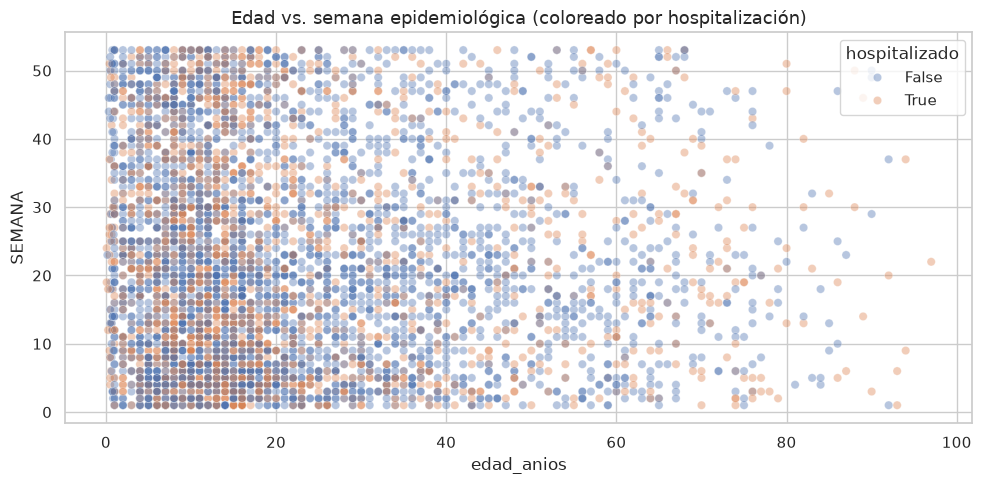

In [28]:
muestra = df_limpio.sample(min(5000, len(df_limpio)), random_state=42)
sns.scatterplot(data=muestra, x="edad_anios", y="SEMANA", hue="hospitalizado", alpha=0.4)
plt.title("Edad vs. semana epidemiológica (coloreado por hospitalización)")
plt.tight_layout()
plt.show()

## 7.3. Casos por territorio y perfil clínico

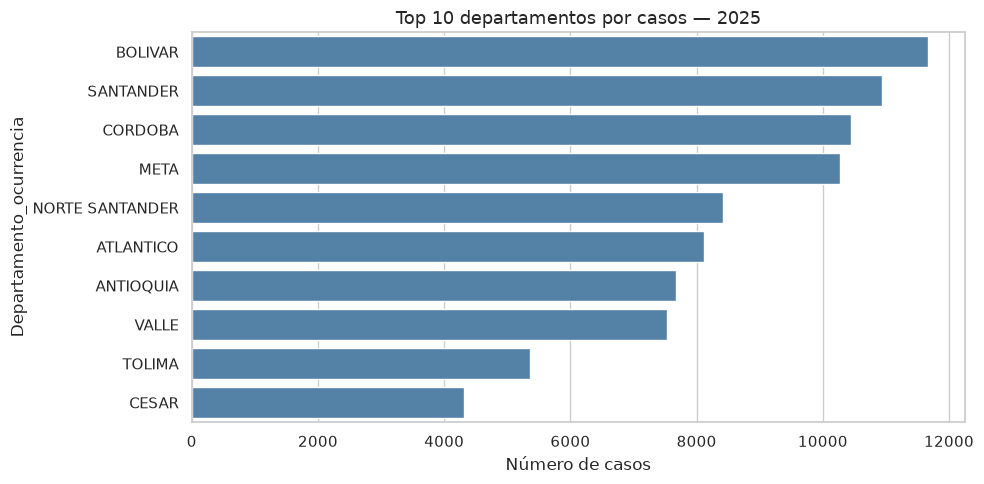

In [29]:
top_deptos = df_limpio["Departamento_ocurrencia"].value_counts().head(10).index
df_top = df_limpio[df_limpio["Departamento_ocurrencia"].isin(top_deptos)]

sns.countplot(data=df_top, y="Departamento_ocurrencia", order=top_deptos, color="steelblue")
plt.title(f"Top 10 departamentos por casos — {ANIO}")
plt.xlabel("Número de casos")
plt.tight_layout()
plt.show()

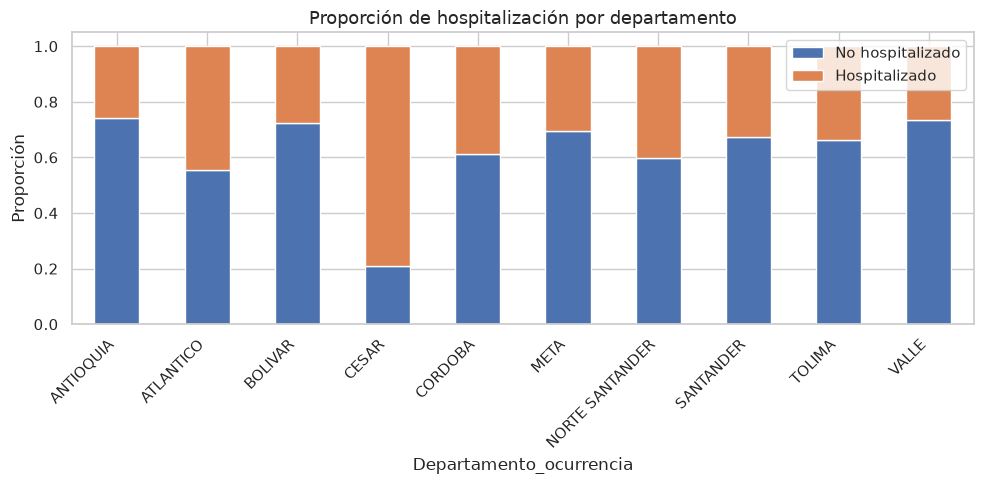

,No hospitalizado,Hospitalizado
Departamento_ocurrencia,,
ANTIOQUIA,0.743,0.257
ATLANTICO,0.554,0.446
BOLIVAR,0.723,0.277
CESAR,0.210,0.790
CORDOBA,0.614,0.386
META,0.694,0.306
NORTE SANTANDER,0.597,0.403
SANTANDER,0.673,0.327
TOLIMA,0.662,0.338


In [30]:
# Hospitalización por departamento (top 10)
tabla_hosp = pd.crosstab(
    df_top["Departamento_ocurrencia"],
    df_top["hospitalizado"],
    normalize="index",
)
tabla_hosp.columns = ["No hospitalizado", "Hospitalizado"]
tabla_hosp.plot(kind="bar", stacked=True, title="Proporción de hospitalización por departamento")
plt.ylabel("Proporción")
plt.xticks(rotation=45, ha="right")
plt.legend(loc="upper right")
plt.tight_layout()
plt.show()
tabla_hosp.round(3)

In [31]:
# Edad media y % hospitalización por sexo
resumen_sexo = df_limpio.groupby("SEXO").agg(
    casos=("CONSECUTIVE", "count"),
    edad_media=("edad_anios", "mean"),
    pct_hospitalizado=("hospitalizado", "mean"),
    pct_confirmado=("confirmado", "mean"),
).round(3)
resumen_sexo

,casos,edad_media,pct_hospitalizado,pct_confirmado
SEXO,,,,
F,57626,22.902,0.374,0.752
M,62938,22.108,0.370,0.749


## 7.4. Estacionalidad y brotes (H1)

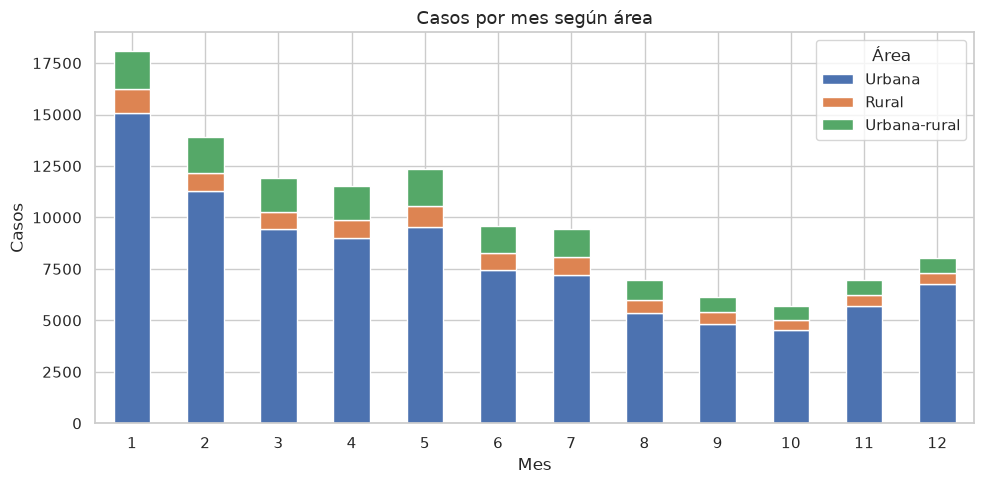

In [32]:
# Casos por mes y por área (urbana/rural)
casos_mes_area = pd.crosstab(df_limpio["mes"], df_limpio["AREA"])
casos_mes_area.columns = ["Urbana", "Rural", "Urbana-rural"][: len(casos_mes_area.columns)]
casos_mes_area.plot(kind="bar", stacked=True, title="Casos por mes según área")
plt.xlabel("Mes")
plt.ylabel("Casos")
plt.xticks(rotation=0)
plt.legend(title="Área")
plt.tight_layout()
plt.show()

## 7.5. Análisis territorial (H2) — sin mapa

Mapas pendientes (requieren shapefiles). Mientras tanto: ranking territorial.

In [33]:
# Top 15 municipios por casos
top_mun = (
    df_limpio.groupby(["Departamento_ocurrencia", "Municipio_ocurrencia"])
    .size()
    .sort_values(ascending=False)
    .head(15)
    .reset_index(name="casos")
)
top_mun

,Departamento_ocurrencia,Municipio_ocurrencia,casos
0,BOLIVAR,CARTAGENA,7142
1,META,VILLAVICENCIO,5506
2,CORDOBA,MONTERIA,4929
3,NORTE SANTANDER,CUCUTA,4799
4,ATLANTICO,BARRANQUILLA,3748
5,SANTANDER,BUCARAMANGA,3246
6,VALLE,CALI,3060
7,MAGDALENA,SANTA MARTA,1747
8,ATLANTICO,SOLEDAD,1716
9,SANTANDER,FLORIDABLANCA,1709


**Interpretación bivariada (completar tras ejecutar):**

- _[H1 estacionalidad: confirmada / refutada — evidencia]_
- _[H2 territorial: confirmada / refutada — evidencia]_
- _[H3 clima: pendiente — requiere IDEAM]_
- _[H4 perfil clínico: confirmada / refutada — evidencia]_

---
# 8. Conclusiones

> *Etapa del flujo: **Conclusiones***

Recordemos la pregunta que orientó todo el análisis:

> **Pregunta SMART:** ¿Puede un sistema de analítica predictiva basado en IA anticipar brotes de dengue con precisión > 80 %, reduciendo ≥ 20 % la mortalidad y ≥ 30 % el tiempo de respuesta sanitaria en un piloto de 6 meses, con datos del INS y el IDEAM?

## 8.1. Contraste de las hipótesis

| Hipótesis | Enunciado | Resultado | Evidencia |
|-----------|---------|-----------|-----------|
| **H1** | Estacionalidad en meses/semanas | _[Confirmada / Refutada / Parcial]_ | _[Sección 6.1, 7.4]_ |
| **H2** | Heterogeneidad territorial | _[Confirmada / Refutada / Parcial]_ | _[Sección 6.3, 7.3, 7.5]_ |
| **H3** | Asociación con variables climáticas | _[Pendiente / Confirmada / Refutada]_ | _[Sección 7.1–7.2]_ |
| **H4** | Perfil clínico difiere por riesgo | _[Confirmada / Refutada / Parcial]_ | _[Sección 6.3, 7.3]_ |
| **H5** | Datos aptos para modelo > 80 % | _[Sí / No / Parcial]_ | _[Calidad EDA global]_ |

## 8.2. Sobre la calidad del conjunto de datos

Completar tras las secciones 4 y 5:

- **Completitud:** _[¿Quedó sin valores críticos faltantes?]_
- **Formato:** _[¿Fechas y tipos corregidos?]_
- **Relevancia:** _[¿Variables predictoras identificadas?]_
- **Tamaño:** _[~872k registros — suficiente para EDA y regresión agregada]_

## 8.3. Limitaciones y recomendaciones

- Integración pendiente de **IDEAM** y **DANE**
- `FEC_DEF` con 100 % nulos — validar otra fuente para mortalidad
- Agregación territorial necesaria antes del modelado
- _[Agregar limitaciones encontradas en el EDA]_

## 8.4. Respuesta a la pregunta de negocio

¿El EDA sugiere que un piloto de 6 meses con precisión > 80 % es **viable** con los datos actuales?

> _[Respuesta argumentada en 1–2 párrafos, vinculando hallazgos del EDA con los indicadores SMART]_


---
# 9. Evidencia de uso de IA generativa

> Requerido por el taller — ver [`docs/taller1/justificacion_ia.md`](../docs/taller1/justificacion_ia.md)

| Pregunta | Respuesta |
|----------|-----------|
| **Herramienta usada** | _[ej. Cursor, ChatGPT, Copilot]_ |
| **Qué partes se hicieron con IA** | _[ej. estructura del notebook, código de carga, gráficos]_ |
| **Qué revisó el equipo** | _[datos, lógica epidemiológica, conclusiones, cifras]_ |
| **Prompts o iteraciones relevantes** | _[opcional — enlazar o resumir]_ |
